# Loss surface illustration

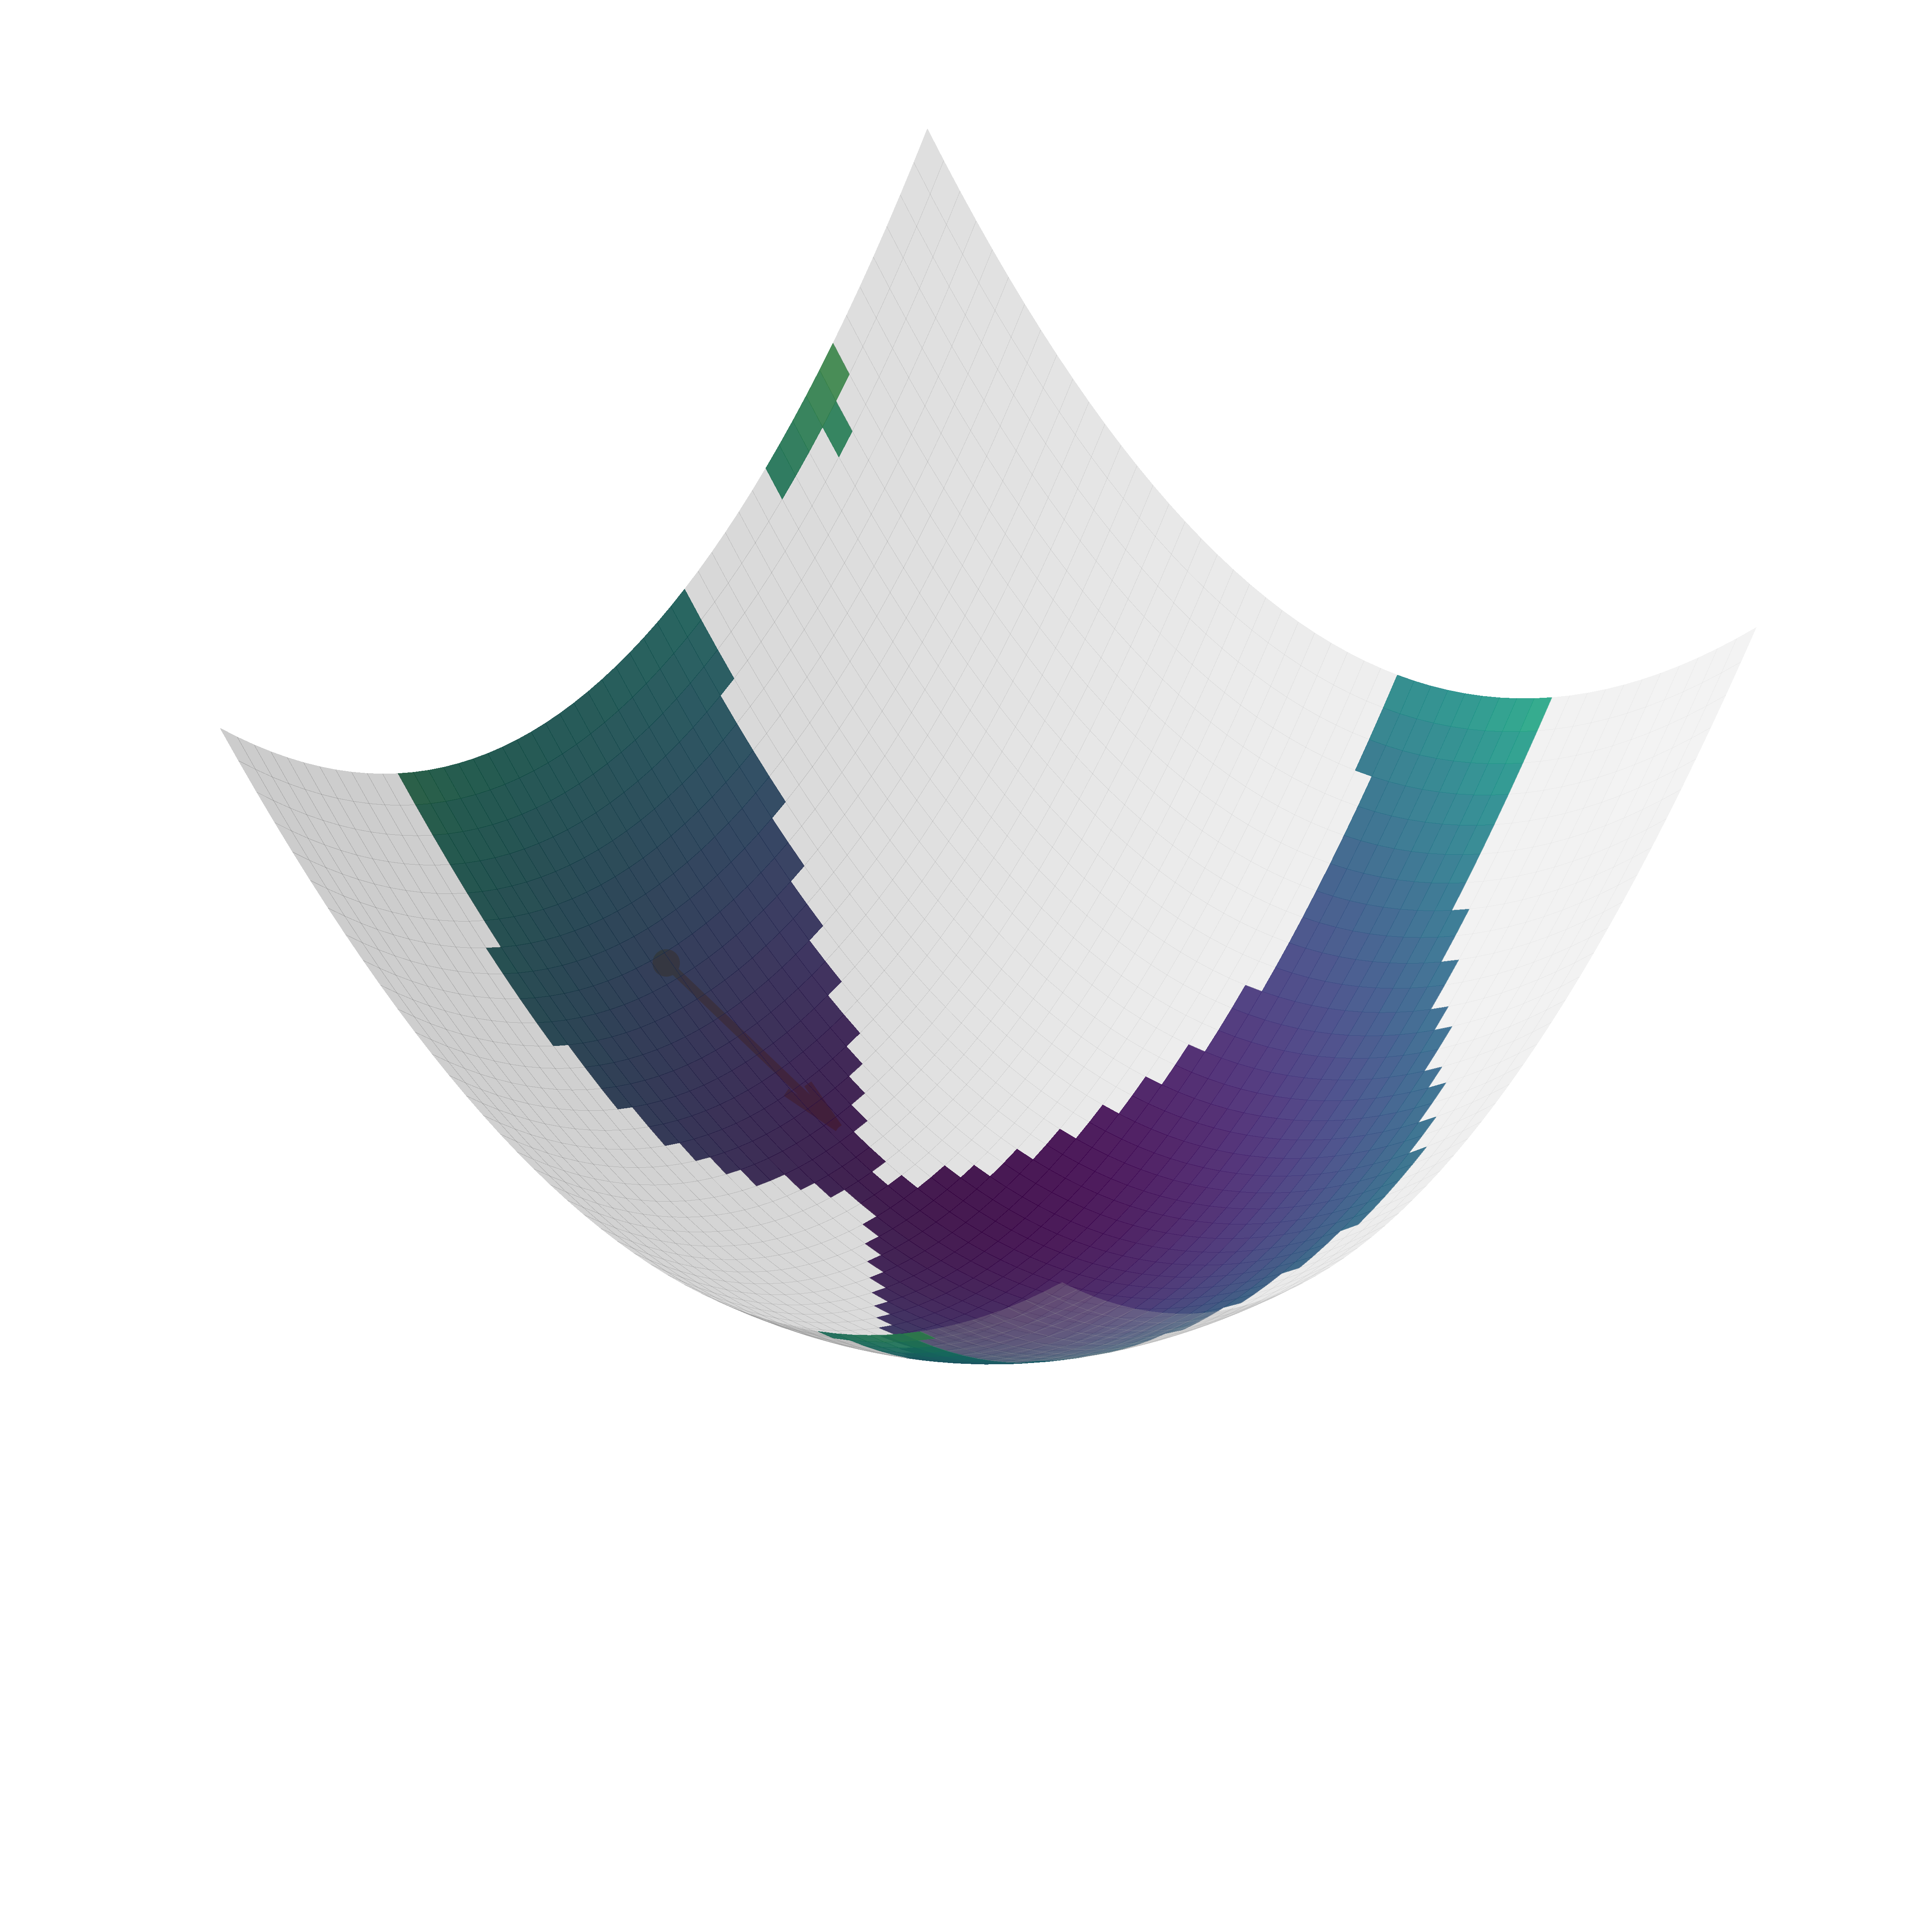

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(8, 8), dpi=600)
ax = fig.add_subplot(111, projection="3d")
plt.rcParams.update({"font.family": "serif"})

n_points = 50
x = np.linspace(-3.0, 3.0, n_points)
y = np.linspace(-3.0, 3.0, n_points)
X1, X2 = np.meshgrid(x, y)

Y_loss = 0.25 * (X1**2 + X2**2)

Z_constraint = (
    np.sin(1.5 * X1)
    + np.cos(1.2 * X2 + 0.5)
    + 0.6 * np.sin(0.8 * X1 * X2)
    - 0.4 * np.cos(2.0 * X1)
)

valid_mask = Z_constraint > 0.2

face_colors = np.zeros(Y_loss.shape + (4,))

norm = plt.Normalize(Y_loss.min(), Y_loss.max())

valid_colors = cm.viridis(norm(Y_loss))
face_colors[valid_mask] = valid_colors[valid_mask]
face_colors[valid_mask, 3] = 0.9

face_colors[~valid_mask] = [0.85, 0.85, 0.85, 0.3]

surf = ax.plot_surface(
    X1,
    X2,
    Y_loss,
    facecolors=face_colors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=True,
)

valid_indices = np.argwhere(valid_mask)

candidates = valid_indices[
    (X1[valid_indices[:, 0], valid_indices[:, 1]] < -1.0)
    & (X1[valid_indices[:, 0], valid_indices[:, 1]] > -2.0)
]

if len(candidates) > 0:
    idx = candidates[len(candidates) // 2]
    p_x1 = X1[idx[0], idx[1]]
    p_x2 = X2[idx[0], idx[1]]
else:
    p_x1, p_x2 = -1.5, -0.5

p_y = 0.25 * (p_x1**2 + p_x2**2)

grad_x1 = 0.5 * p_x1
grad_x2 = 0.5 * p_x2

d_x1 = -grad_x1
d_x2 = -grad_x2
d_y = (grad_x1 * d_x1) + (grad_x2 * d_x2)

length = 1.5
norm_len = np.sqrt(d_x1**2 + d_x2**2 + d_y**2)
v_x1 = (d_x1 / norm_len) * length
v_x2 = (d_x2 / norm_len) * length
v_y = (d_y / norm_len) * length

z_offset = 0.2
ax.quiver(
    p_x1,
    p_x2,
    p_y + z_offset,
    v_x1,
    v_x2,
    v_y,
    color="orange",
    linewidth=2.5,
    arrow_length_ratio=0.25,
    zorder=10,
)
ax.scatter(p_x1, p_x2, p_y + z_offset, color="orange", s=50, zorder=10)


ax.axis("off")

# ax.text(0, -3.5, 0, '$x_1$', fontsize=16, horizontalalignment='center')
# ax.text(-3.5, 0, 0, '$x_2$', fontsize=16, horizontalalignment='center')
# ax.text(0, 0, Y_loss.max() + 0.5, 'Loss $y$', fontsize=16, horizontalalignment='center')

ax.view_init(elev=50, azim=-50)

legend_elements = [
    Patch(facecolor=cm.viridis(0.5), label="Feasible Space"),
    Patch(facecolor=[0.85, 0.85, 0.85], alpha=0.3, label="Infeasible Space"),
    Line2D([0], [0], color="black", lw=2, label="Gradient Step"),
]
# ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=12)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
# plt.savefig('figures/figure1/loss.svg', format='svg', transparent=True, bbox_inches='tight')

plt.tight_layout()

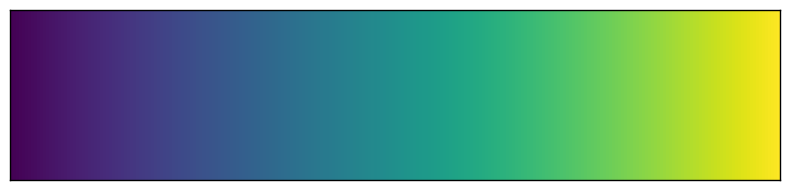

In [3]:
fig_colormap, ax_colormap = plt.subplots(figsize=(8, 2))
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax_colormap.imshow(gradient, aspect="auto", cmap=cm.viridis)

ax_colormap.set_xticks([])
ax_colormap.set_yticks([])

for spine in ax_colormap.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

plt.tight_layout()

# plt.savefig('figures/figure1/viridis-colors.svg', format='svg', transparent=True, bbox_inches='tight')

# Single cell features

In [1]:
from common import *

get(
    "machinable.index",
    "./index",
).__enter__()

machinable.index [987188]

In [153]:
len(qq)

15

In [15]:
_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

c = _ca1_sopt_baseline.components.filter(
    lambda x: x.cell_type == "PVBC" and x.mO == "-"
)[0]

qq = c.get_best()["x"].iloc[-1].to_dict()
qq.update(c.config.dopt_params.problem_parameters)

qq

numprocs=1


2025-12-16 00:06:01.222412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-16 00:06:01.243719: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-16 00:06:01.243758: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-16 00:06:01.257540: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-16 00:06:02.340032: W tensorflow/compiler/tf

{'Ltotal': 37.62028884887695,
 'cm_ratio': 3.903846025466919,
 'dend_beta_Caconc': 0.03191220387816429,
 'dend_d_Caconc': 17.446317672729492,
 'dend_g_pas': 0.0004252658982295543,
 'dend_gmax_Ca': 0.8048859238624573,
 'dend_gmax_KCa': 1.0,
 'gc': 23.3135986328125,
 'pp': 0.10000000149011612,
 'soma_g_pas': 0.0016516740433871746,
 'soma_gmax_K': 0.0010000000474974513,
 'soma_gmax_Na': 0.898166298866272,
 'e_pas': -62,
 'global_cm': 3.0,
 'global_diam': 10.0}

In [16]:
import matplotlib.pyplot as plt
from neuron import h
from scipy import optimize
import logging
import pprint
from benchmarks.modeling.utils import ic_constant_f, load_template, run_vclamp
from benchmarks.modeling.ephys import (
    detect_spikes,
    measure_passive,
    measure_rn_from_vclamp,
)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)




def run_iclamp(
    cell,
    amp,
    t0,
    t1,
    dt=0.025,
    record_dt=0.01,
    t_stop=1000.0,
    v_init=-65.0,
    celsius=36,
    use_coreneuron=False,
    cvode=False
):
    h.load_file("stdrun.hoc")
    # h.load_file("rn.hoc")

    # Enable variable time step solver
    h.cvode.use_fast_imem(1)
    h.cvode.cache_efficient(1)
    h.cvode.active(1 if cvode else 0)
    h.secondorder = 2
    h.dt = 0.025

    # Create the recording vectors for time and voltage
    vec_t = h.Vector()
    vec_soma_v = h.Vector()
    vec_dend_v = h.Vector()
    vec_dend_ica = h.Vector()
    vec_dend_ik = h.Vector()
    vec_soma_ik = h.Vector()
    vec_soma_ina = h.Vector()
    # vec_soma_ica = h.Vector()
    # vec_soma_cai = h.Vector()
    vec_dend_cai = h.Vector()
    vec_dend_ki = h.Vector()
    vec_soma_ki = h.Vector()
    vec_soma_g_Na = h.Vector()
    vec_soma_g_Kdr = h.Vector()
    vec_soma_g_KCa = h.Vector()
    vec_soma_g_CaN = h.Vector()
    vec_dend_g_KCa = h.Vector()
    vec_dend_g_CaN = h.Vector()
    vec_dend_g_CaL = h.Vector()

    vec_t.record(h._ref_t, record_dt)  # Time
    vec_soma_v.record(cell.soma(0.5)._ref_v, record_dt)  # Voltage
    vec_soma_ik.record(cell.soma(0.5)._ref_ik, record_dt)
    vec_soma_ina.record(cell.soma(0.5)._ref_ina, record_dt)
    # vec_soma_ica.record(cell.soma(0.5)._ref_ica, record_dt)
    # vec_soma_cai.record(cell.soma(0.5)._ref_cai, record_dt)
    vec_soma_ki.record(cell.soma(0.5)._ref_ki, record_dt)

    vec_soma_g_Na.record(cell.soma(0.5)._ref_g_Na_PR, record_dt)
    vec_soma_g_Kdr.record(cell.soma(0.5)._ref_g_K_PR, record_dt)
    # vec_soma_g_KCa.record(cell.soma(0.5)._ref_g_KCa_PR, record_dt)
    # vec_soma_g_CaN.record(cell.soma(0.5)._ref_g_Ca, record_dt)

    vec_dend_v.record(cell.dend(0.5)._ref_v, record_dt)  # Voltage
    vec_dend_cai.record(cell.dend(0.5)._ref_cai, record_dt)
    vec_dend_ki.record(cell.dend(0.5)._ref_ki, record_dt)
    vec_dend_ica.record(cell.dend(0.5)._ref_ica, record_dt)
    vec_dend_ik.record(cell.dend(0.5)._ref_ik, record_dt)

    vec_dend_g_KCa.record(cell.dend(0.5)._ref_g_KCa_PR, record_dt)
    vec_dend_g_CaN.record(cell.dend(0.5)._ref_g_Ca_PR, record_dt)
    # vec_dend_g_CaL.record(cell.dend(0.5)._ref_g_CaL, record_dt)

    # Put an IClamp at the soma
    stim = h.IClamp(0.5, sec=cell.soma)

    VecT = h.Vector(amp)
    VecT.play(stim._ref_amp, dt)
    stim.delay = t0  # Stimulus stat
    stim.dur = t1 - t0  # Stimulus length
    # stim.amp = amp  # strength of current injection

    # Run the Simulation
    h.dt = dt
    h.celsius = celsius
    h.v_init = v_init
    h.init()
    h.finitialize(h.v_init)
    logger.info(f"soma ek = {cell.soma.ek} ena = {cell.soma.ena}")
    logger.info(f"dend ek = {cell.dend.ek} eca = {cell.dend.eca}")
    logger.info(f"soma nao = {cell.soma.nao} ko = {cell.soma.ko}")
    logger.info(f"dend ki = {cell.soma.ki} ko = {cell.dend.ko}")
    logger.info(f"dend cao = {cell.dend.cao} cai = {cell.dend.cai}")

    h.tstop = t_stop
    if use_coreneuron:
        from neuron import coreneuron

        coreneuron.enable = True
    h.run()

    result_dict = {
        "t": np.array(vec_t),
        "soma_v": np.array(vec_soma_v),
        "dend_v": np.array(vec_dend_v),
        "soma_ik": np.array(vec_soma_ik),
        "soma_ki": np.array(vec_soma_ki),
        "soma_ina": np.array(vec_soma_ina),
        "dend_ica": np.array(vec_dend_ica),
        "dend_cai": np.array(vec_dend_cai),
        "dend_ki": np.array(vec_dend_ki),
        "dend_ik": np.array(vec_dend_ik),
        "soma_g_Na": np.array(vec_soma_g_Na),
        "soma_g_Kdr": np.array(vec_soma_g_Kdr),
        # "soma_g_KCa": np.array(vec_soma_g_KCa),
        # "soma_g_CaN": np.array(vec_soma_g_CaN),
        # "dend_g_CaL": np.array(vec_dend_g_CaL),
        "dend_g_CaN": np.array(vec_dend_g_CaN),
        "dend_g_KCa": np.array(vec_dend_g_KCa),
        "stim_amp": amp
    }

    return result_dict


def run_component_iclamp(
    component,
    cvode=False,
    dt=0.025,
    model_variant="default",
    target_namespace="",
    v_init_config="rest",
    ic_constant=False,
    stim_start=0, #500.0,
    stim_stop=2000. ,#1000.0,
    t_stop=2000.0,
    coreneuron=False,
    stim_amp=0.08,
    passive_features=False,
    param_dict=None,
):
    # config_dict = None
    # with open(config_path) as f:
    #     config_dict = yaml.load(f, Loader=yaml.FullLoader)
    config_dict = component.config.dopt_params.obj_fun_init_args.protocol_config_dict

    template_dict = config_dict.get("Template", None)
    template_name = None
    template_file = None
    template = None
    if template_dict is None:
        template_name = "MN_nrn"
        template_file = "MN_nrn.hoc"
    else:
        if model_variant in template_dict:
            template_name = template_dict[model_variant]["name"]
            template_file = template_dict[model_variant].get("file", None)
        else:
            raise RuntimeError(f"Unknown model variant {model_variant}")

    from miv_simulator.mechanisms import compile_and_load

    compile_and_load("benchmarks/ca1_pinsky_rinzel_modeling/mechanisms")

    template = load_template(
        template_name,
        os.path.join("benchmarks/ca1_pinsky_rinzel_modeling", template_file),
    )

    target_config = config_dict["Targets"]
    if target_namespace:
        target_config = config_dict["Target namespaces"][target_namespace]
    Rin_config = target_config["Rin"]
    tau0_config = target_config["tau0"]

    # toplevel_param_dict = config_dict.get(toplevel_param_key, None)
    # if toplevel_param_dict is None:
    #     raise RuntimeError(f"Unable to read {toplevel_param_key} configuration")

    # param_dict = toplevel_param_dict.get(param_key, None)
    # if param_dict is None:
    #     param_dict = toplevel_param_dict[int(param_key)]

    if param_dict is None:
        best = component.get_best(sort_by="-np.max(y, axis=1)", epsilon="auto")
        param_dict = best["x"].iloc[-1].to_dict()
        feature_dict = best["f"].iloc[-1].to_dict()
        param_dict.update(
            {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
        )

    param_dict.update(component.config.dopt_params.problem_parameters)

    logger.info(f"{pprint.pformat(param_dict)}")

    if v_init_config == "rest":
        v_init = config_dict["Targets"]["V_rest"]["val"]
    elif v_init_config == "hold":
        v_init = config_dict["Targets"]["V_hold"]["val"]
    else:
        raise RuntimeError(f"Unknown v_init configuration {v_init}")

    cell = template(param_dict)

    h.v_init = v_init
    h.init()
    h.finitialize(h.v_init)
    cell.init_ic(h.v_init)
    ic_constant_0 = cell.soma.ic_constant
    ic_constant_val = ic_constant_0

    # Obtain value for ic_constant such that RMP = v_init
    if ic_constant:
        try:
            x0, res = optimize.brentq(
                ic_constant_f,
                -0.1,
                0.1,
                args=(template, param_dict, ic_constant_0, h.v_init),
                xtol=1e-6,
                maxiter=200,
                disp=False,
                full_output=True,
            )
        except ValueError:
            x0 = 0.0
        else:
            if not res.converged:
                x0 = 0.0
        ic_constant_val = x0 + ic_constant_0
    else:
        if v_init_config == "rest":
            ic_constant_val = param_dict["ic_constant_rest"]
        elif v_init_config == "hold":
            ic_constant_val = param_dict["ic_constant_hold"]
        else:
            raise RuntimeError(f"Unknown v_init configuration {v_init}")

    cell.soma.ic_constant = ic_constant_val
    h.finitialize(h.v_init)
    h.finitialize(h.v_init)

    h.psection(sec=cell.soma)
    h.psection(sec=cell.dend)

    initial_v_error = ic_constant_f(
        0.0,
        template,
        param_dict,
        cell.soma.ic_constant,
        v_hold=v_init,
        use_cvode=cvode,
    )
    logger.info(f"initial_v_error: {initial_v_error}")
    initial_v_constr = (
        1 if np.isclose(0.0, initial_v_error, rtol=1e-4, atol=1e-4) else 0
    )

    logger.info(f"ic_constant0: {ic_constant_0}")
    logger.info(f"ic_constant: {ic_constant_val}")
    logger.info(f"mean initial vm constraint: {initial_v_constr}")

    stim = np.zeros([int((t_stop) / dt)])
    stim[10000:20000] = stim_amp
    stim[30000:40000] = 2*stim_amp
    stim[50000:60000] = 3*stim_amp

    return run_iclamp(
        cell,
        stim,
        stim_start,
        stim_stop,
        t_stop=t_stop,
        v_init=v_init,
        dt=dt,
        use_coreneuron=coreneuron,
        cvode=cvode
    )




In [17]:
points = []

for p in [100, 500, 1000, 5000]:
    best = c.load_h5()
    w = best["parameters"].iloc[p].to_dict()
    feature_dict = best["features"].iloc[p].to_dict()
    w.update(
        {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
    )
    points.append(w)

points.append(None)

In [18]:
iclamp_results = []
for point in points:
    iclamp_results.append(run_component_iclamp(c, param_dict=point))

INFO:__main__:{'Ltotal': 16.466087341308594,
 'cm_ratio': 10.046796798706055,
 'dend_beta_Caconc': 0.032501690089702606,
 'dend_d_Caconc': 19.107269287109375,
 'dend_g_pas': 0.0007180337561294436,
 'dend_gmax_Ca': 0.5588555932044983,
 'dend_gmax_KCa': 0.35162749886512756,
 'e_pas': -62,
 'gc': 40.548011779785156,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.05398649349808693,
 'ic_constant_rest': -0.10776801407337189,
 'pp': 0.19512465596199036,
 'soma_g_pas': 0.009702456183731556,
 'soma_gmax_K': 0.9146262407302856,
 'soma_gmax_Na': 0.2737649083137512}


PRN_nrn[0].soma { nseg=1  L=3.21294  Ra=11654.1
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=30.1404}
	insert pas { g_pas=0.00970246 e_pas=-62}
	insert constant { ic_constant=-0.107768}
	insert Na_PR { gmax_Na_PR=0.273765}
	insert K_PR { gmax_K_PR=0.914626}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=13.2531  Ra=684.927
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.000718034 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.558856}
	insert KCa_PR { gmax_KCa_PR=0.351627}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=19.1073 beta_Ca_conc_PR=0.0325017}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.

INFO:__main__:initial_v_error: -3.827967603342586e-06
INFO:__main__:ic_constant0: -0.07564916908714248
INFO:__main__:ic_constant: -0.10776801407337189
INFO:__main__:mean initial vm constraint: 1
INFO:__main__:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:__main__:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:__main__:soma nao = 145.0 ko = 5.0
INFO:__main__:dend ki = 145.0 ko = 5.0
INFO:__main__:dend cao = 2.0 cai = 1e-05
INFO:__main__:{'Ltotal': 48.87242889404297,
 'cm_ratio': 37.5695915222168,
 'dend_beta_Caconc': 0.017764726653695107,
 'dend_d_Caconc': 5.799697399139404,
 'dend_g_pas': 7.260101847350597e-05,
 'dend_gmax_Ca': 0.7448608875274658,
 'dend_gmax_KCa': 0.9174968004226685,
 'e_pas': -62,
 'gc': 27.375812530517578,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.05256763845682144,
 'ic_constant_rest': -0.09959807246923447,
 'pp': 0.20460842549800873,
 'soma_g_pas': 0.006362986750900745,
 'soma_gmax_K': 0.9066839218139648,
 'soma_gmax_Na

PRN_nrn[0].soma { nseg=1  L=9.99971  Ra=1868.62
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=112.709}
	insert pas { g_pas=0.00636299 e_pas=-62}
	insert constant { ic_constant=-0.0995981}
	insert Na_PR { gmax_Na_PR=0.118035}
	insert K_PR { gmax_K_PR=0.906684}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=38.8727  Ra=123.654
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=7.2601e-05 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.744861}
	insert KCa_PR { gmax_KCa_PR=0.917497}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=5.7997 beta_Ca_conc_PR=0.0177647}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2

INFO:__main__:{'Ltotal': 28.244548797607422,
 'cm_ratio': 44.84563446044922,
 'dend_beta_Caconc': 0.06696054339408875,
 'dend_d_Caconc': 7.6357502937316895,
 'dend_g_pas': 0.001959997694939375,
 'dend_gmax_Ca': 0.8590909242630005,
 'dend_gmax_KCa': 0.877977728843689,
 'e_pas': -62,
 'gc': 44.88371658325195,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.026497427374124527,
 'ic_constant_rest': -0.035725921392440796,
 'pp': 0.257515549659729,
 'soma_g_pas': 0.0005103438161313534,
 'soma_gmax_K': 0.6233619451522827,
 'soma_gmax_Na': 0.5784080624580383}
INFO:__main__:initial_v_error: -0.15601903206170675
INFO:__main__:ic_constant0: -0.0003819051555577768
INFO:__main__:ic_constant: -0.035725921392440796
INFO:__main__:mean initial vm constraint: 0
INFO:__main__:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:__main__:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:__main__:soma nao = 145.0 ko = 5.0
INFO:__main__:dend ki = 145.0 ko = 5.0
INFO:__main__:den

PRN_nrn[0].soma { nseg=1  L=7.27341  Ra=2711.31
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=134.537}
	insert pas { g_pas=0.000510344 e_pas=-62}
	insert constant { ic_constant=-0.0357259}
	insert Na_PR { gmax_Na_PR=0.578408}
	insert K_PR { gmax_K_PR=0.623362}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=20.9711  Ra=326.145
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.00196 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.859091}
	insert KCa_PR { gmax_KCa_PR=0.877978}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=7.63575 beta_Ca_conc_PR=0.0669605}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 

INFO:__main__:{'Ltotal': 21.119064331054688,
 'cm_ratio': 1.7294557094573975,
 'dend_beta_Caconc': 0.009999999776482582,
 'dend_d_Caconc': 14.677047729492188,
 'dend_g_pas': 0.002730470383539796,
 'dend_gmax_Ca': 0.5131343603134155,
 'dend_gmax_KCa': 0.9430598616600037,
 'e_pas': -62,
 'gc': 23.574108123779297,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.08040215820074081,
 'ic_constant_rest': -0.14110137522220612,
 'pp': 0.1071864441037178,
 'soma_g_pas': 0.0025500671472400427,
 'soma_gmax_K': 0.9149758219718933,
 'soma_gmax_Na': 0.8999999761581421}
INFO:__main__:initial_v_error: 3.354377365383243e-05
INFO:__main__:ic_constant0: -0.005443395557123684
INFO:__main__:ic_constant: -0.14110137522220612
INFO:__main__:mean initial vm constraint: 1
INFO:__main__:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:__main__:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:__main__:soma nao = 145.0 ko = 5.0
INFO:__main__:dend ki = 145.0 ko = 5.0
INFO:__main__:d

PRN_nrn[0].soma { nseg=1  L=2.26368  Ra=22182.8
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=5.18837}
	insert pas { g_pas=0.00255007 e_pas=-62}
	insert constant { ic_constant=-0.141101}
	insert Na_PR { gmax_Na_PR=0.9}
	insert K_PR { gmax_K_PR=0.914976}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=18.8554  Ra=319.723
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.00273047 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.513134}
	insert KCa_PR { gmax_KCa_PR=0.94306}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=14.677 beta_Ca_conc_PR=0.01}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_

INFO:__main__:{'Ltotal': 37.62028884887695,
 'cm_ratio': 3.903846025466919,
 'dend_beta_Caconc': 0.03191220387816429,
 'dend_d_Caconc': 17.446317672729492,
 'dend_g_pas': 0.0004252658982295543,
 'dend_gmax_Ca': 0.8048859238624573,
 'dend_gmax_KCa': 1.0,
 'e_pas': -62,
 'gc': 23.3135986328125,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.014534338377416134,
 'ic_constant_rest': 0.013448840007185936,
 'pp': 0.10000000149011612,
 'soma_g_pas': 0.0016516740433871746,
 'soma_gmax_K': 0.0010000000474974513,
 'soma_gmax_Na': 0.898166298866272}
INFO:__main__:initial_v_error: 57.0
INFO:__main__:ic_constant0: 0.0642531663274575
INFO:__main__:ic_constant: 0.013448840007185936
INFO:__main__:mean initial vm constraint: 0
INFO:__main__:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:__main__:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:__main__:soma nao = 145.0 ko = 5.0
INFO:__main__:dend ki = 145.0 ko = 5.0
INFO:__main__:dend cao = 2.0 cai = 1e-05


PRN_nrn[0].soma { nseg=1  L=3.76203  Ra=7576.81
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=11.7115}
	insert pas { g_pas=0.00165167 e_pas=-62}
	insert constant { ic_constant=0.0134488}
	insert Na_PR { gmax_Na_PR=0.898166}
	insert K_PR { gmax_K_PR=0.001}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=33.8583  Ra=93.5409
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.000425266 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.804886}
	insert KCa_PR { gmax_KCa_PR=1}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=17.4463 beta_Ca_conc_PR=0.0319122}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_co

In [ ]:
#stash("figure1-iclamp_results", [{k: v.tolist() for k, v in ir.items() if k in ['t', 'soma_v', 'stim_amp']} for ir in iclamp_results])
#iclamp_results = restore("figure1-iclamp_results")

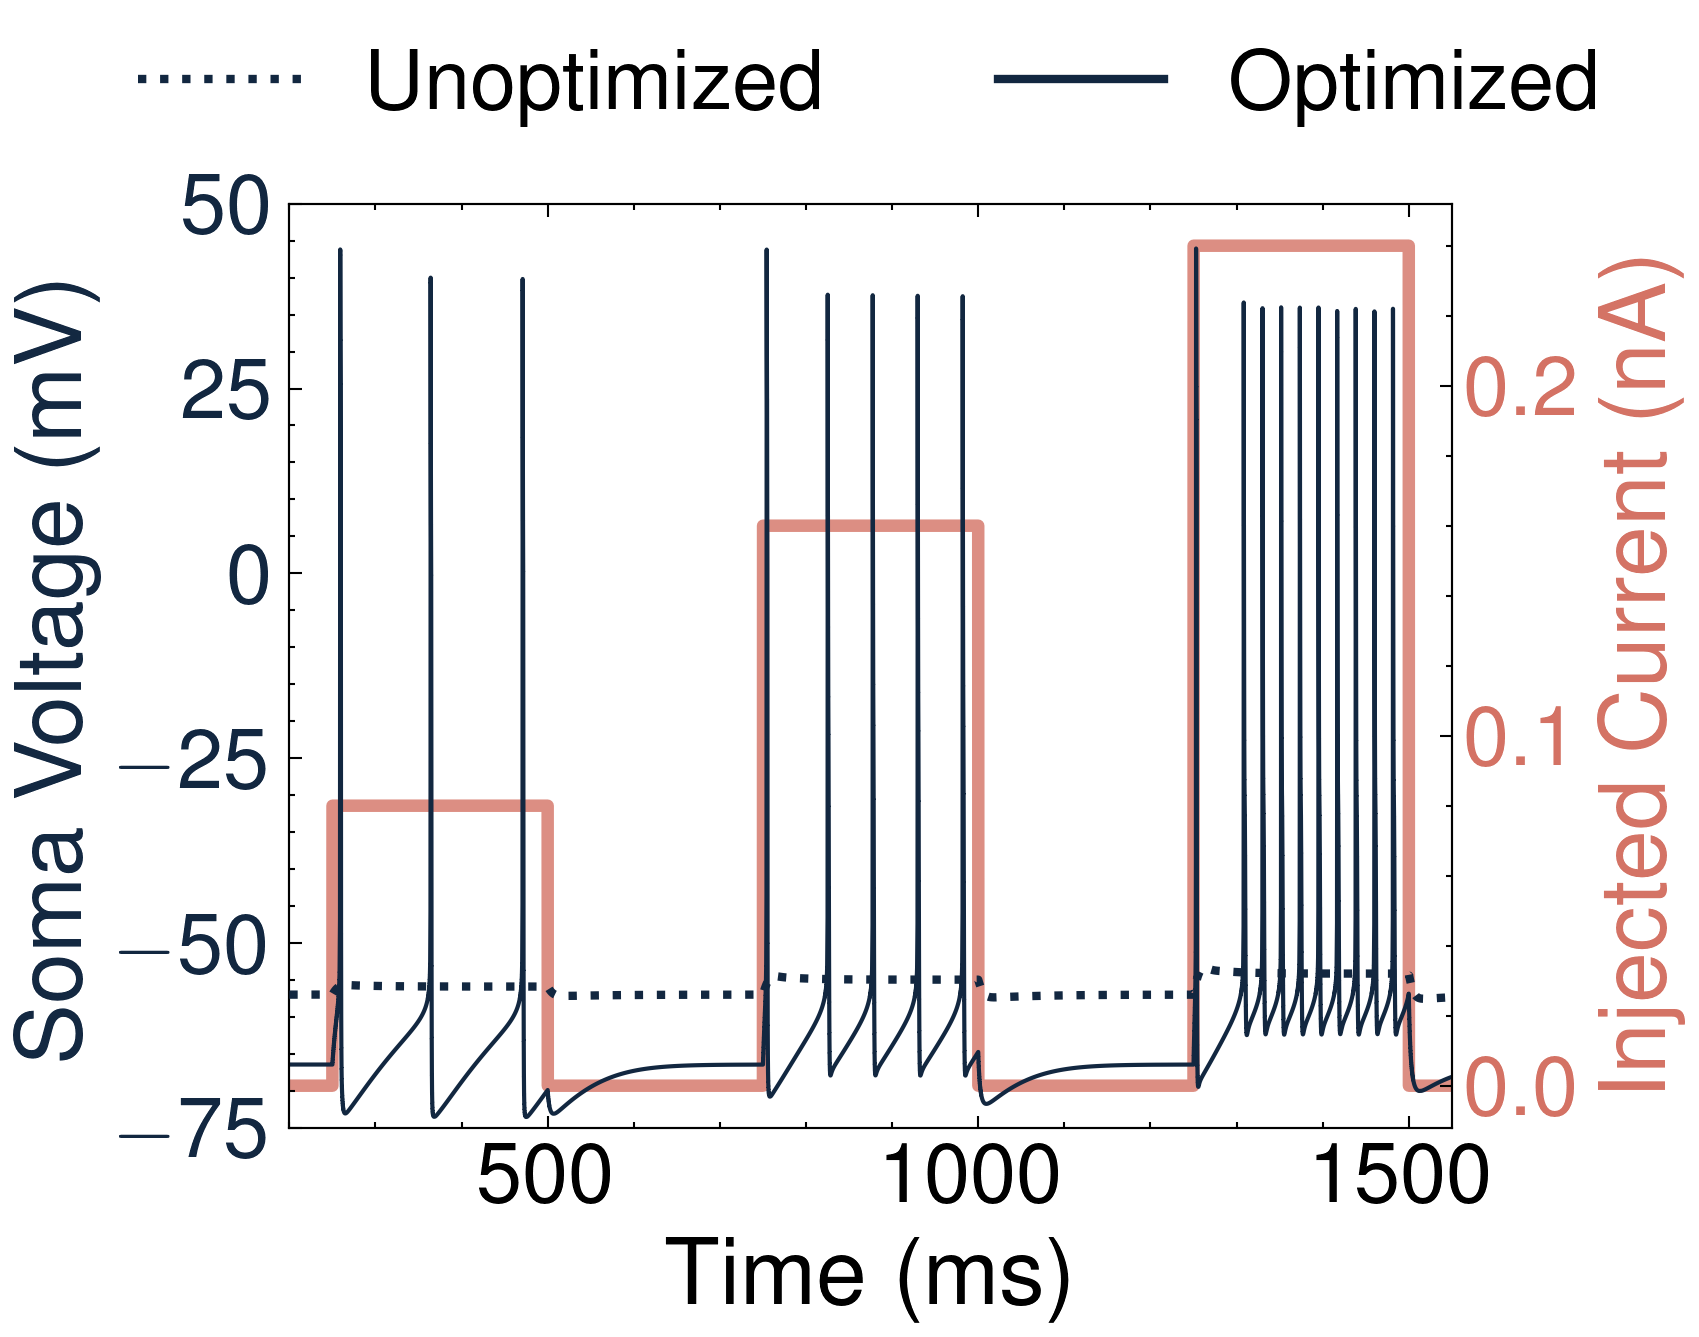

In [19]:
from matplotlib.lines import Line2D

iclamp_result = iclamp_results[-1]

vec_t = iclamp_result["t"]
vec_soma_v = iclamp_result["soma_v"]
stim_amp = iclamp_result["stim_amp"]


fig, ax1 = plt.subplots(figsize=(5, 4))

SMALL_SIZE = 20
MEDIUM_SIZE = 22
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

c1 = "#d47264"
c2 = "#122740"
c3 = "#b8b8b8"



ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Soma Voltage (mV)", color=c2)
ax1.plot(vec_t, vec_soma_v, color=c2, label='Soma Voltage', linestyle='-', zorder=2)
ax1.tick_params(axis='y', labelcolor=c2)

ax1.plot(vec_t, iclamp_results[1]["soma_v"],
          color=c2, 
          linewidth=2,
         label='Soma Voltage Unopt',
         linestyle=':'
         , zorder=3)
ax1.set_ylim([-75, 50])
ax1.set_xlim([200, 1550])


ax2 = ax1.twinx()
ax2.set_ylabel("Injected Current (nA)", color=c1)
ax2.plot(np.arange(0, 2000., 0.025), stim_amp, color=c1, linestyle='-', 
         label='Injected Current', linewidth=3, zorder=1, alpha=0.8)
ax2.tick_params(axis='y', labelcolor=c1)

ax1.set_zorder(ax2.get_zorder()+1)
ax1.patch.set_visible(False)

#ax1.legend(loc='upper left')
#ax2.legend(loc='upper right')

legend_elements = [
    Line2D([0], [0], color=c2, lw=2, linestyle=':', label='Unoptimized'),
    Line2D([0], [0], color=c2, lw=2, label='Optimized'),
]
ax1.legend(handles=legend_elements, loc='upper center', 
           bbox_to_anchor=(0.5, 1.25), ncol=2, frameon=False)

In [152]:
stash("figure1/soma-fI", fig)